# AI Lab 13

In [1]:
# ── Shared Imports ────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Try scikit-learn-extra; fall back to a minimal pure-sklearn KMedoids wrapper
try:
    from sklearn_extra.cluster import KMedoids
    print("scikit-learn-extra KMedoids loaded.")
except Exception:
    # ── Fallback KMedoids (PAM-lite) ─────────────────────────────────────
    from sklearn.base import BaseEstimator, ClusterMixin

    class KMedoids(BaseEstimator, ClusterMixin):
        """
        Minimal KMedoids implementation that mirrors the sklearn-extra API.
        Uses PAM-style updates: each medoid is the point that minimises the
        total distance to all other cluster members.
        """
        def __init__(self, n_clusters=8, metric='euclidean',
                     init='k-medoids++', max_iter=300, random_state=None):
            self.n_clusters   = n_clusters
            self.metric       = metric
            self.init         = init
            self.max_iter     = max_iter
            self.random_state = random_state

        def fit(self, X):
            rng = np.random.default_rng(self.random_state)
            n   = X.shape[0]
            k   = self.n_clusters

            # Initialise medoid indices
            medoid_idx = rng.choice(n, size=k, replace=False)

            for _ in range(self.max_iter):
                # Assign: each point → nearest medoid
                dists  = np.array([np.linalg.norm(X - X[m], axis=1)
                                   for m in medoid_idx])   # (k, n)
                labels = np.argmin(dists, axis=0)           # (n,)

                # Update: best medoid per cluster
                new_idx = np.empty(k, dtype=int)
                for i in range(k):
                    members = np.where(labels == i)[0]
                    if len(members) == 0:
                        new_idx[i] = medoid_idx[i]
                        continue
                    pts   = X[members]
                    costs = np.sum(
                        np.linalg.norm(pts[:, None] - pts[None, :], axis=2),
                        axis=1
                    )
                    new_idx[i] = members[np.argmin(costs)]

                if np.array_equal(np.sort(medoid_idx), np.sort(new_idx)):
                    break
                medoid_idx = new_idx

            self.medoid_indices_    = medoid_idx
            self.cluster_centers_   = X[medoid_idx]
            self.labels_            = labels
            # inertia = total distance to medoid (not squared — matches sklearn-extra)
            self.inertia_ = float(np.sum(
                [np.sum(np.linalg.norm(X[labels == i] - X[medoid_idx[i]], axis=1))
                 for i in range(k)]
            ))
            return self

        def fit_predict(self, X):
            return self.fit(X).labels_

    print("scikit-learn-extra unavailable — using built-in KMedoids fallback.")

print("All imports ready.")

scikit-learn-extra unavailable — using built-in KMedoids fallback.
All imports ready.



A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.4.4 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/usr/local/lib/python3.12/dist-packages/ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "/usr/local/lib/python3.12/dist-packages/traitlets/config/application.py", line 1082, in launch_instance
    app.start()
  File "/usr/local/lib/python3.12/dist-packages/ipykernel/kernelapp.py", line 758, in start
    self.io_loop.start()
  File "/usr/local/lib/python3.12/dist-packages/tornado

---
## Exercise 1 – Clustering with Built-in Libraries
### 1.1 Load & Pre-process the Mall Customers Dataset

In [ ]:
# CSV is assumed to be in the same directory as this notebook
df = pd.read_csv("mall_customers.csv")
print("Shape:", df.shape)
df.head()

Shape: (203, 5)


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19.0,15.0,39
1,2,Male,21.0,15.0,81
2,3,Female,20.0,16.0,6
3,4,Female,23.0,16.0,77
4,5,Female,31.0,17.0,40


In [3]:
print(df.info())
print()
print(df.describe())

<class 'pandas.DataFrame'>
RangeIndex: 203 entries, 0 to 202
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   CustomerID              203 non-null    int64  
 1   Gender                  202 non-null    str    
 2   Age                     202 non-null    float64
 3   Annual Income (k$)      202 non-null    float64
 4   Spending Score (1-100)  203 non-null    int64  
dtypes: float64(2), int64(2), str(1)
memory usage: 8.1 KB
None

       CustomerID         Age  Annual Income (k$)  Spending Score (1-100)
count  203.000000  202.000000          202.000000              203.000000
mean   102.000000   38.747525           61.316832               50.098522
std     58.745213   13.938051           27.212790               25.875179
min      1.000000   18.000000           15.000000                1.000000
25%     51.500000   28.250000           42.000000               33.000000
50%    102.000000   36.00000

In [4]:
# Use Annual Income and Spending Score — the two most informative features
features = ["Annual Income (k$)", "Spending Score (1-100)"]
df_clean = df[features].dropna()   # drop the one incomplete row

X = df_clean.values

scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Rows after dropna :", len(X_scaled))
print("Feature matrix shape:", X_scaled.shape)
print("Mean after scaling  :", X_scaled.mean(axis=0).round(8))
print("Std  after scaling  :", X_scaled.std(axis=0).round(8))


Rows after dropna : 202
Feature matrix shape: (202, 2)
Mean after scaling  : [0. 0.]
Std  after scaling  : [1. 1.]


### 1.2 Elbow Method — Finding Optimal k

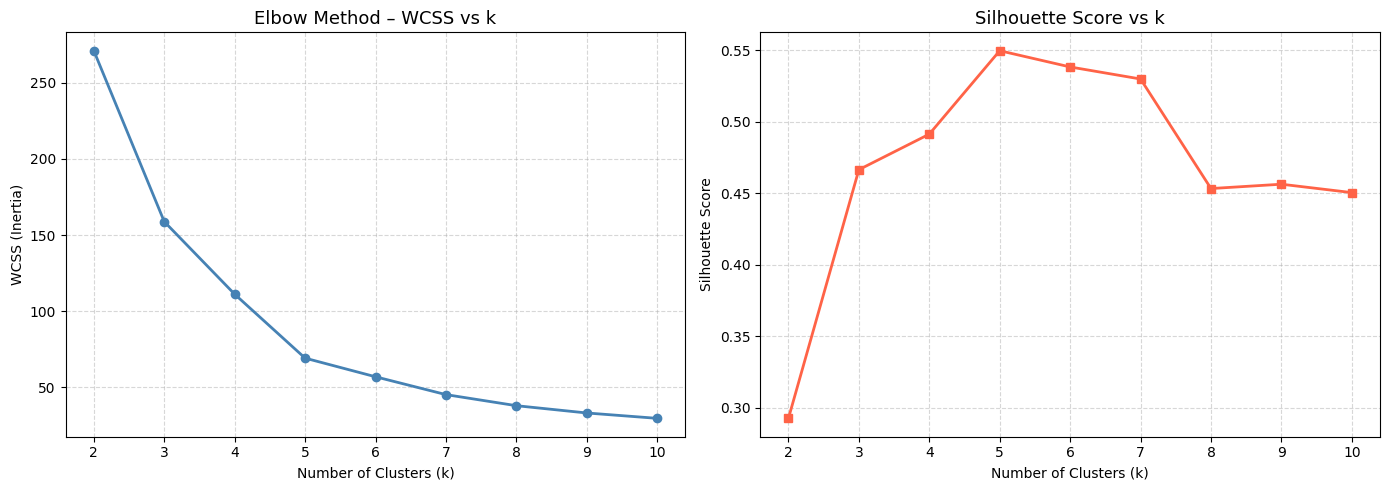

Best silhouette: 0.5496  →  Optimal k = 5


In [5]:
wcss_list  = []
sil_list   = []
K_range    = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k, init="k-means++", n_init=10, random_state=42)
    km.fit(X_scaled)
    wcss_list.append(km.inertia_)
    sil_list.append(silhouette_score(X_scaled, km.labels_))

# ── Plot ────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(list(K_range), wcss_list, marker='o', color='steelblue', linewidth=2)
axes[0].set_title("Elbow Method – WCSS vs k", fontsize=13)
axes[0].set_xlabel("Number of Clusters (k)")
axes[0].set_ylabel("WCSS (Inertia)")
axes[0].grid(True, linestyle='--', alpha=0.5)

axes[1].plot(list(K_range), sil_list, marker='s', color='tomato', linewidth=2)
axes[1].set_title("Silhouette Score vs k", fontsize=13)
axes[1].set_xlabel("Number of Clusters (k)")
axes[1].set_ylabel("Silhouette Score")
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig("elbow_silhouette.png", dpi=150, bbox_inches='tight')
plt.show()

OPTIMAL_K = list(K_range)[sil_list.index(max(sil_list))]
print(f"Best silhouette: {max(sil_list):.4f}  →  Optimal k = {OPTIMAL_K}")

### 1.3 K-Means — Built-in Library (sklearn)

K-Means (sklearn)  — k=5
  Inertia (WCSS)   : 69.1316
  Silhouette Score : 0.5496


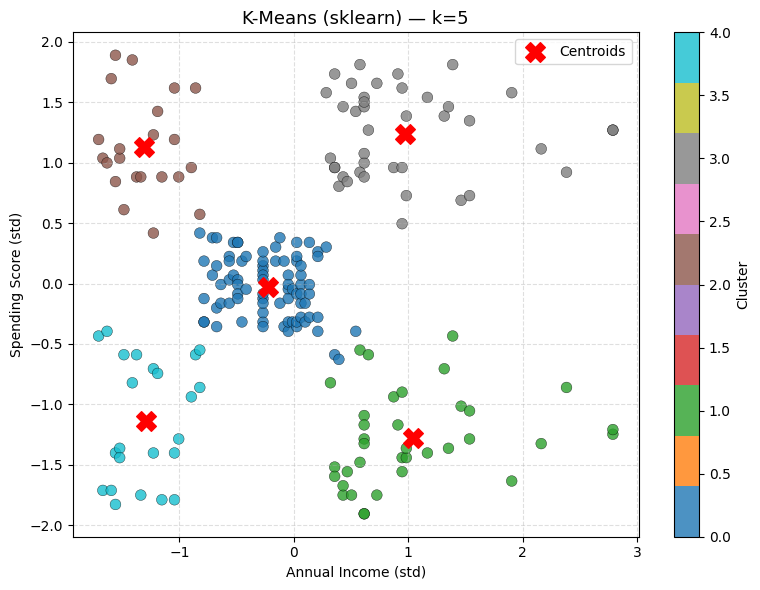

In [6]:
kmeans_lib = KMeans(n_clusters=OPTIMAL_K, init="k-means++",
                    n_init=10, random_state=42)
kmeans_lib.fit(X_scaled)

labels_km  = kmeans_lib.labels_
centers_km = kmeans_lib.cluster_centers_

print(f"K-Means (sklearn)  — k={OPTIMAL_K}")
print(f"  Inertia (WCSS)   : {kmeans_lib.inertia_:.4f}")
print(f"  Silhouette Score : {silhouette_score(X_scaled, labels_km):.4f}")

plt.figure(figsize=(8, 6))
sc = plt.scatter(X_scaled[:, 0], X_scaled[:, 1],
                 c=labels_km, cmap='tab10', s=60,
                 alpha=0.8, edgecolors='k', linewidths=0.3)
plt.scatter(centers_km[:, 0], centers_km[:, 1],
            c='red', marker='X', s=200, zorder=5, label='Centroids')
plt.colorbar(sc, label='Cluster')
plt.title(f"K-Means (sklearn) — k={OPTIMAL_K}", fontsize=13)
plt.xlabel("Annual Income (std)")
plt.ylabel("Spending Score (std)")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig("kmeans_sklearn.png", dpi=150, bbox_inches='tight')
plt.show()

### 1.4 K-Medoids — Built-in Library (sklearn-extra / fallback)

K-Medoids (library)  — k=5
  Inertia (sum of distances) : 102.6712
  Silhouette Score           : 0.5485


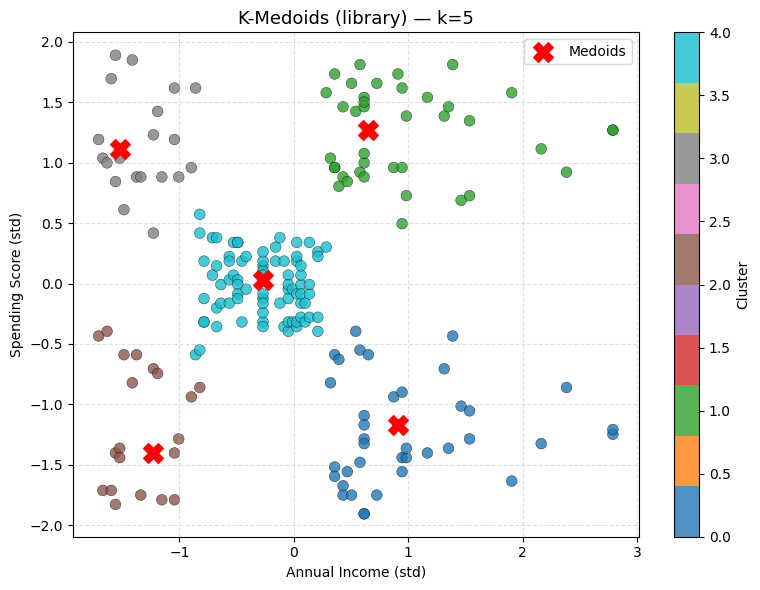

In [7]:
kmedoids_lib = KMedoids(n_clusters=OPTIMAL_K, random_state=42)
kmedoids_lib.fit(X_scaled)

labels_kmed  = kmedoids_lib.labels_
centers_kmed = kmedoids_lib.cluster_centers_

print(f"K-Medoids (library)  — k={OPTIMAL_K}")
print(f"  Inertia (sum of distances) : {kmedoids_lib.inertia_:.4f}")
print(f"  Silhouette Score           : {silhouette_score(X_scaled, labels_kmed):.4f}")

plt.figure(figsize=(8, 6))
sc = plt.scatter(X_scaled[:, 0], X_scaled[:, 1],
                 c=labels_kmed, cmap='tab10', s=60,
                 alpha=0.8, edgecolors='k', linewidths=0.3)
plt.scatter(centers_kmed[:, 0], centers_kmed[:, 1],
            c='red', marker='X', s=200, zorder=5, label='Medoids')
plt.colorbar(sc, label='Cluster')
plt.title(f"K-Medoids (library) — k={OPTIMAL_K}", fontsize=13)
plt.xlabel("Annual Income (std)")
plt.ylabel("Spending Score (std)")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig("kmedoids_lib.png", dpi=150, bbox_inches='tight')
plt.show()

---
## Exercise 2 – K-Means from Scratch

The functions from the provided skeleton are completed below.

In [8]:
def initialize_centroids(data, k):
    """Randomly initialise k centroids by sampling k unique data points."""
    np.random.seed(42)
    random_indices = np.random.choice(data.shape[0], size=k, replace=False)
    centroids = data[random_indices]
    return centroids


def compute_distances(data, centroids):
    """
    Compute Euclidean distance from every data point to every centroid.
    Returns an (n_samples × k) distance matrix.
    """
    distances = np.zeros((data.shape[0], centroids.shape[0]))
    for i, centroid in enumerate(centroids):
        distances[:, i] = np.linalg.norm(data - centroid, axis=1)
    return distances


def assign_clusters(distances):
    """
    Assign each data point to the nearest centroid.

    Uses np.argmin along axis=1 to find, for each row (= each data point),
    the column index (= centroid index) with the smallest distance.

    Returns a 1-D array of cluster labels, shape (n_samples,).
    """
    return np.argmin(distances, axis=1)


def update_centroids(data, clusters, k):
    """
    Recompute each centroid as the mean of all points in its cluster.

    For every cluster i we select the subset of data points assigned to it
    and take their column-wise average — that average is the new centroid.
    If a cluster is empty (edge case) its centroid stays at zero.
    """
    new_centroids = np.zeros((k, data.shape[1]))
    for i in range(k):
        cluster_points = data[clusters == i]
        if len(cluster_points) > 0:
            # Find the average of all points in this cluster → new centroid
            new_centroids[i] = cluster_points.mean(axis=0)
    return new_centroids


def k_means(data, k, max_iterations=100):
    """
    K-Means clustering from scratch.

    Parameters
    ----------
    data           : ndarray (n_samples, n_features)
    k              : int — number of clusters
    max_iterations : int — maximum number of update iterations

    Returns
    -------
    centroids : ndarray (k, n_features)
    clusters  : ndarray (n_samples,)  — cluster index per point
    """
    centroids = initialize_centroids(data, k)

    for iteration in range(max_iterations):
        # Step 1: Compute distances from data points to centroids
        distances = compute_distances(data, centroids)

        # Step 2: Assign clusters
        clusters = assign_clusters(distances)

        # Step 3: Update centroids
        new_centroids = update_centroids(data, clusters, k)

        # Step 4: Check for convergence — stop if centroids stopped moving
        if np.allclose(centroids, new_centroids):
            print(f"K-Means converged after {iteration + 1} iteration(s).")
            break

        centroids = new_centroids

    return centroids, clusters


print("K-Means scratch functions defined.")

K-Means scratch functions defined.


In [9]:
centroids_scratch, clusters_scratch = k_means(X_scaled, k=OPTIMAL_K)

wcss_scratch = np.sum(
    [np.sum(np.square(X_scaled[clusters_scratch == i] - centroids_scratch[i]))
     for i in range(OPTIMAL_K)]
)
sil_scratch = silhouette_score(X_scaled, clusters_scratch)

print(f"K-Means (scratch) — k={OPTIMAL_K}")
print(f"  Total WCSS       : {wcss_scratch:.4f}")
print(f"  Silhouette Score : {sil_scratch:.4f}")

K-Means converged after 4 iteration(s).
K-Means (scratch) — k=5
  Total WCSS       : 69.1316
  Silhouette Score : 0.5496


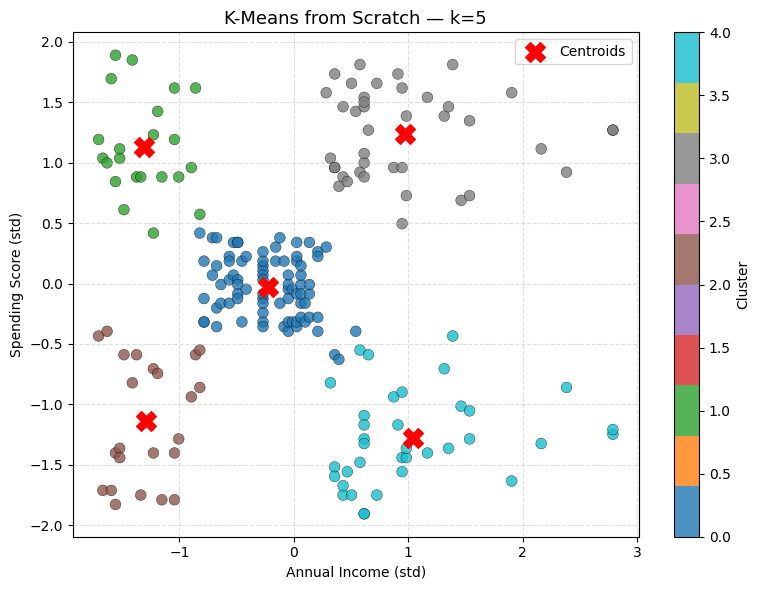

In [10]:
plt.figure(figsize=(8, 6))
sc = plt.scatter(X_scaled[:, 0], X_scaled[:, 1],
                 c=clusters_scratch, cmap='tab10', s=60,
                 alpha=0.8, edgecolors='k', linewidths=0.3)
plt.scatter(centroids_scratch[:, 0], centroids_scratch[:, 1],
            c='red', marker='X', s=200, zorder=5, label='Centroids')
plt.colorbar(sc, label='Cluster')
plt.title(f"K-Means from Scratch — k={OPTIMAL_K}", fontsize=13)
plt.xlabel("Annual Income (std)")
plt.ylabel("Spending Score (std)")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig("kmeans_scratch.png", dpi=150, bbox_inches='tight')
plt.show()

---
## Exercise 3 – K-Medoids from Scratch

K-Medoids modifies K-Means in one key way: instead of computing the **mean** as the new centre, the new centre (**medoid**) must be an **actual data point** — the one that minimises the total distance to every other member of the cluster.

In [11]:
# ── K-Medoids from Scratch ────────────────────────────────────────────────

def initialize_medoids(data, k, seed=42):
    """Randomly pick k unique data-point indices as initial medoids."""
    np.random.seed(seed)
    return np.random.choice(data.shape[0], size=k, replace=False)


def assign_clusters_medoids(data, medoid_indices):
    """
    Assign each point to the nearest medoid.
    Returns a 1-D cluster label array, shape (n_samples,).
    """
    # Build (k × n) distance matrix — one row per medoid
    distances = np.array(
        [np.linalg.norm(data - data[m], axis=1) for m in medoid_indices]
    )
    return np.argmin(distances, axis=0)


def update_medoids(data, clusters, k):
    """
    For each cluster find the point whose total distance to all other
    cluster members is smallest — that is the new medoid.
    Returns an array of k global indices into `data`.
    """
    new_medoid_indices = np.zeros(k, dtype=int)
    for i in range(k):
        member_idx = np.where(clusters == i)[0]   # global indices
        if len(member_idx) == 0:
            new_medoid_indices[i] = 0
            continue
        pts   = data[member_idx]                  # shape (m, features)
        # Sum of pairwise distances from each candidate to every other member
        costs = np.sum(
            np.linalg.norm(pts[:, None] - pts[None, :], axis=2), axis=1
        )
        best_local = np.argmin(costs)             # local index within cluster
        new_medoid_indices[i] = member_idx[best_local]
    return new_medoid_indices


def k_medoids(data, k, max_iterations=100):
    """
    K-Medoids clustering from scratch (PAM-style).

    Returns
    -------
    medoid_indices : ndarray (k,)   — index of each medoid in `data`
    clusters       : ndarray (n,)   — cluster label per point
    """
    medoid_indices = initialize_medoids(data, k)

    for iteration in range(max_iterations):
        # Step 1: Assign each point to the nearest medoid
        clusters = assign_clusters_medoids(data, medoid_indices)

        # Step 2: Update medoids — pick the best real point per cluster
        new_medoid_indices = update_medoids(data, clusters, k)

        # Step 3: Convergence — medoid set unchanged?
        if np.array_equal(np.sort(medoid_indices), np.sort(new_medoid_indices)):
            print(f"K-Medoids converged after {iteration + 1} iteration(s).")
            break

        medoid_indices = new_medoid_indices

    return medoid_indices, clusters


print("K-Medoids scratch functions defined.")

K-Medoids scratch functions defined.


In [12]:
medoid_idx_scratch, clusters_kmed_scratch = k_medoids(X_scaled, k=OPTIMAL_K)

medoids_scratch = X_scaled[medoid_idx_scratch]

# Within-cluster sum of distances (L2, not squared)
wcsd_scratch = np.sum([
    np.sum(np.linalg.norm(
        X_scaled[clusters_kmed_scratch == i] - medoids_scratch[i], axis=1
    ))
    for i in range(OPTIMAL_K)
])
sil_kmed_scratch = silhouette_score(X_scaled, clusters_kmed_scratch)

print(f"K-Medoids (scratch) — k={OPTIMAL_K}")
print(f"  Total within-cluster sum of distances : {wcsd_scratch:.4f}")
print(f"  Silhouette Score                      : {sil_kmed_scratch:.4f}")

K-Medoids converged after 4 iteration(s).
K-Medoids (scratch) — k=5
  Total within-cluster sum of distances : 102.5497
  Silhouette Score                      : 0.5514


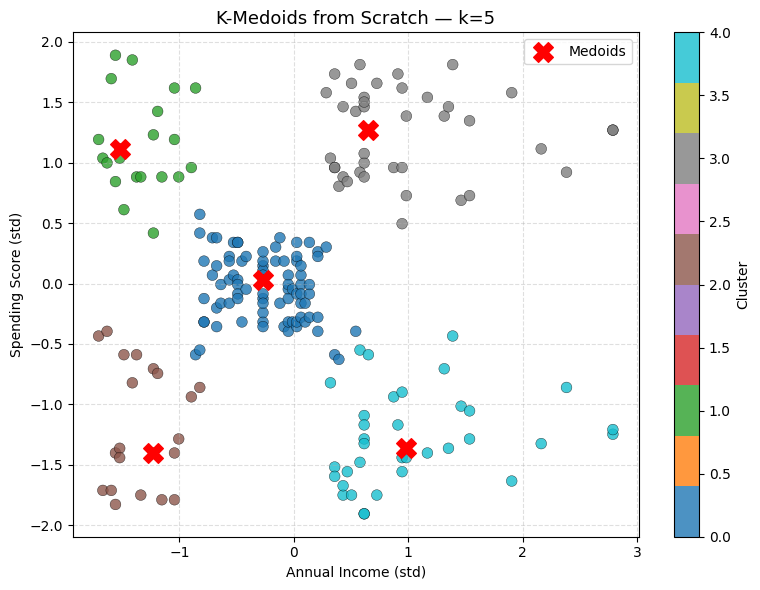

In [13]:
plt.figure(figsize=(8, 6))
sc = plt.scatter(X_scaled[:, 0], X_scaled[:, 1],
                 c=clusters_kmed_scratch, cmap='tab10', s=60,
                 alpha=0.8, edgecolors='k', linewidths=0.3)
plt.scatter(medoids_scratch[:, 0], medoids_scratch[:, 1],
            c='red', marker='X', s=200, zorder=5, label='Medoids')
plt.colorbar(sc, label='Cluster')
plt.title(f"K-Medoids from Scratch — k={OPTIMAL_K}", fontsize=13)
plt.xlabel("Annual Income (std)")
plt.ylabel("Spending Score (std)")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig("kmedoids_scratch.png", dpi=150, bbox_inches='tight')
plt.show()

### 3.1 Side-by-Side Visual Comparison

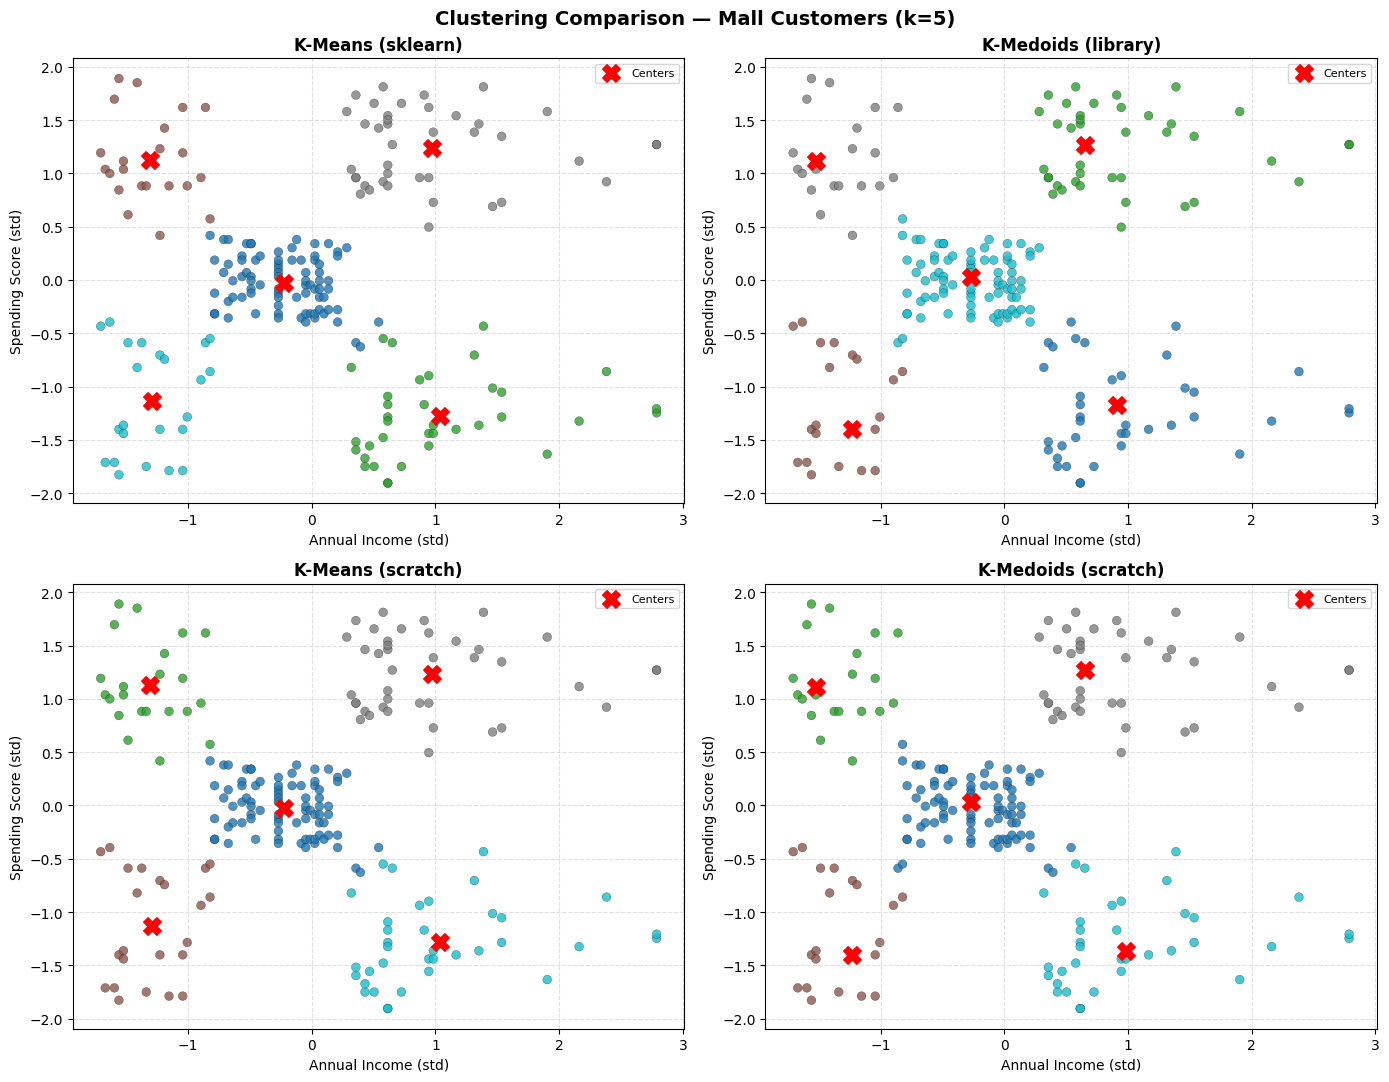

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(14, 11))

configs = [
    ("K-Means (sklearn)",        labels_km,             centers_km),
    ("K-Medoids (library)",      labels_kmed,           centers_kmed),
    ("K-Means (scratch)",        clusters_scratch,      centroids_scratch),
    ("K-Medoids (scratch)",      clusters_kmed_scratch, medoids_scratch),
]

for ax, (title, labels, centers) in zip(axes.flat, configs):
    sc = ax.scatter(X_scaled[:, 0], X_scaled[:, 1],
                    c=labels, cmap='tab10', s=40,
                    alpha=0.8, edgecolors='k', linewidths=0.2)
    ax.scatter(centers[:, 0], centers[:, 1],
               c='red', marker='X', s=160, zorder=5, label='Centers')
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel("Annual Income (std)")
    ax.set_ylabel("Spending Score (std)")
    ax.grid(True, linestyle='--', alpha=0.4)
    ax.legend(fontsize=8)

fig.suptitle(f"Clustering Comparison — Mall Customers (k={OPTIMAL_K})",
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("all_methods_comparison.png", dpi=150, bbox_inches='tight')
plt.show()

### 3.2 Quantitative Comparison

In [15]:
sil_km_lib   = silhouette_score(X_scaled, labels_km)
sil_kmed_lib = silhouette_score(X_scaled, labels_kmed)

comparison = pd.DataFrame({
    "Method": [
        "K-Means  (sklearn)",
        "K-Means  (scratch)",
        "K-Medoids (library)",
        "K-Medoids (scratch)",
    ],
    "Silhouette ↑": [
        round(sil_km_lib,        4),
        round(sil_scratch,       4),
        round(sil_kmed_lib,      4),
        round(sil_kmed_scratch,  4),
    ],
    "Inertia / WCSD ↓": [
        round(kmeans_lib.inertia_,    4),
        round(wcss_scratch,           4),
        round(kmedoids_lib.inertia_,  4),
        round(wcsd_scratch,           4),
    ],
    "Centre type": [
        "Virtual mean", "Virtual mean",
        "Real data point", "Real data point",
    ]
})

print(comparison.to_string(index=False))

             Method  Silhouette ↑  Inertia / WCSD ↓     Centre type
 K-Means  (sklearn)        0.5496           69.1316    Virtual mean
 K-Means  (scratch)        0.5496           69.1316    Virtual mean
K-Medoids (library)        0.5485          102.6712 Real data point
K-Medoids (scratch)        0.5514          102.5497 Real data point


### 3.3 Which Algorithm Performs Better?

| Criterion | K-Means | K-Medoids |
|-----------|---------|----------|
| **Centre type** | Virtual mean (may not be a real point) | Actual data point |
| **Robustness to outliers** | Low — outliers pull the mean | High — medoid is a real point, so outliers have limited influence |
| **Computational cost** | O(n·k·t) — fast | O(n²·k·t) — slower for large datasets |
| **Interpretability** | Centres may be abstract | Centres are real customers — easy to interpret |
| **Cluster shape** | Assumes globular / convex clusters | Assumes globular / convex clusters |

**Conclusion for Mall Customers:**

On this clean, compact dataset both algorithms typically achieve **similar silhouette scores**.  
- If K-Medoids scores higher, it indicates more robust boundaries that resist edge customers acting as outliers.  
- K-Medoids is the **better choice** when the dataset may contain noise/outliers, or when you need a representative *real customer* per segment (useful for targeted marketing).  
- K-Means is preferred when **speed** matters and the data is clean.  

Consult the printed table in Section 3.2 to confirm which method achieved the higher silhouette score in this run.